<html> <h1 style="font-style:bold; color:blue;"> Neural Computing and Deep Learning </h1> </html>

<html> <h1 style="font-style:italic; color:blue;"> Week-6 </h1> </html>

<html> <h2 style="font-style:italic; color:blue;"> RNN for Time Series </h2> </html>


RNNs are used for sequence modelling. This tutorial will look at time series data to be modelled and predicted using RNNs. 

In [1]:
# Import Libraries

import pandas as pd
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt

## Data

We will use retail data for time-series modeling. 

Link to the dataset:
https://fred.stlouisfed.org/series/MRTSSM448USN

Information about the Advance Monthly Retail Sales Survey can be found on the Census website at:
https://www.census.gov/retail/marts/about_the_surveys.html

Release: Advance Monthly Sales for Retail and Food Services  
Units:  Millions of Dollars, Not Seasonally Adjusted
Frequency:  Monthly

Suggested Citation:
U.S. Census Bureau, Advance Retail Sales: Clothing and Clothing Accessory Stores [RSCCASN], retrieved from FRED, Federal Reserve Bank of St. Louis; https://fred.stlouisfed.org/series/RSCCASN, January 25, 2025.




##### Read data first -  Use index_col = 'DATE' and 'parse_dates = True' as a parameter.

In [2]:
# Read data

df = pd.read_csv('MRTSSM448USN_24.csv',index_col='observation_date',parse_dates=True)


In [3]:
# Print the first few rows of data

df.head()

,MRTSSM448USN
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


In [4]:
df.tail()

,MRTSSM448USN
observation_date,
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318
2024-11-01,29762
2024-12-01,41199


Does the sales column has any name?

If no, set the name of the colum as 'Sales'.

In [5]:
# Set name of column as 'Sales'. Use - df.columns 

df.columns = ['Sales']

df.head()

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


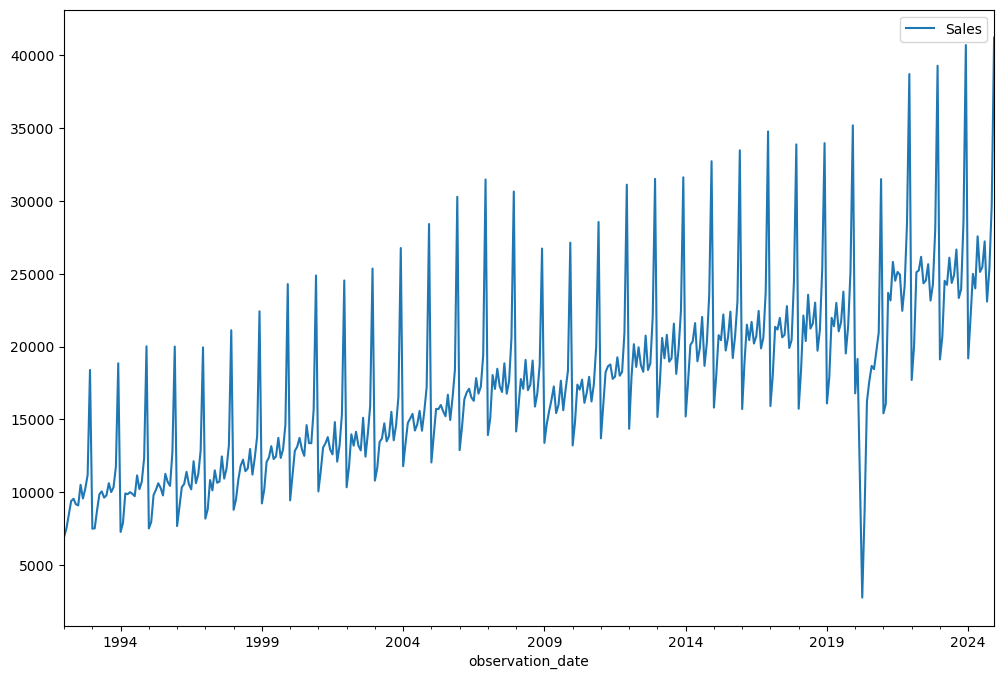

In [6]:
# Plot Year vs Sales

df.plot(figsize=(12,8))

plt.show()

### Train Test Split 

We will use the last 1.5 years (18 months) samples for testing. The rest is for training

In [7]:
# Assign variable test size = 18

test_size = 18
test_size

18

In [8]:
# Store length of data in variable length.

data_length = len(df)
data_length

396

In [21]:
len(df) - 18

378

In [9]:
# Store training size in variable train_size 
# (Remember training size = total size - test_size)

train_size = data_length- test_size
train_size

378

Now, we will find the indexes of the test data. Remember, these are the last 18 indexes in the pandas dataframe

In [10]:
# Assign the start of the test index in dataframe to variable test_index.  
# Remember, it is equal to the length of dataframe - test size

test_index =  train_size
test_index

378

Next, we will separate train and test datasets.

In [11]:
# Store all data from 0 to test_index in variable train. 

train = df.iloc[:test_index]
train

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2023-02-01,20666
2023-03-01,24510
2023-04-01,24232


In [12]:
# Store everything from test_index to the last sample in the test variable
# Hint - Use df.iloc

test = df.iloc[test_index:]
test

,Sales
observation_date,
2023-07-01,24911
2023-08-01,26657
2023-09-01,23332
2023-10-01,23933
2023-11-01,28580
2023-12-01,40684
2024-01-01,19188
2024-02-01,22005
2024-03-01,24986


In [13]:
# Print the size of the train data
# Print the size of the test data

print(train.size)
print(test.size)

378
18


### In Neural Networks, we need to Scale Data between 0-1

In [14]:
from sklearn.preprocessing import MinMaxScaler

In [15]:
scaler = MinMaxScaler()
scaler.fit(train)

MinMaxScaler()

In [16]:
scaled_train = scaler.transform(train)
scaled_test = scaler.transform(test)

In [17]:
# Check if the data has been scaled properly
# Print max and min for train and test

print(scaled_train.max())
print(scaled_test.max())
print(scaled_train.min())
print(scaled_test.min())

1.0
1.0530599939704552
0.0
0.44980403979499545


## Time Series Generator

This class takes in a sequence of data-points gathered at
equal intervals, along with time series parameters such as
stride, length of history, etc., to produce batches for
training/validation.


#### Arguments
    data: Indexable generator (such as list or Numpy array)
        containing consecutive data points (timesteps).
        The data should be at 2D, and axis 0 is expected
        to be the time dimension.
    targets: Targets corresponding to timesteps in `data`.
        It should have same length as `data`.
    length: Length of the output sequences (in number of timesteps).
    sampling_rate: Period between successive individual timesteps
        within sequences. For rate `r`, timesteps
        `data[i]`, `data[i-r]`, ... `data[i - length]`
        are used for create a sample sequence.
    stride: Period between successive output sequences.
        For stride `s`, consecutive output samples would
        be centered around `data[i]`, `data[i+s]`, `data[i+2*s]`, etc.
    start_index: Data points earlier than `start_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    end_index: Data points later than `end_index` will not be used
        in the output sequences. This is useful to reserve part of the
        data for test or validation.
    shuffle: Whether to shuffle output samples,
        or instead draw them in chronological order.
    reverse: Boolean: if `true`, timesteps in each output sample will be
        in reverse chronological order.
    batch_size: Number of timeseries samples in each batch
        (except maybe the last one).
        


### We will use 12 months as input and then predict the next month out



In [18]:
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator

In [48]:
#TimeseriesGenerator?

In [19]:
# Let's redefine to get 12 months back and then predict the next month out

length = 12
generator = TimeseriesGenerator(scaled_train, scaled_train, 
                                length=length, batch_size=1)

In [20]:
# What does the first batch look like?

X, y = generator[0]

print(f'Given the Array: \n{X.flatten()}')
print(f'Predict this y: \n {y}')

Given the Array: 
[0.11406802 0.13012854 0.15619262 0.18157152 0.18587442 0.17556938
 0.17340423 0.21204813 0.18628553 0.20494971 0.23052046 0.42807027]
Predict this y: 
 [[0.12952558]]


### Create the Model

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import GRU

import tensorflow as tf

In [23]:
# We're only using one feature in our time series

n_features = 1
n_features

1

## Define your own models. 

Use 1. SimpleRNN, LSTM, or GRU neural network.

APIs:
https://keras.io/api/layers/recurrent_layers/

In [24]:
# Your code to create your own model
# use input_shape=(length, n_features)
# use model.add(Dense(1)) because it is the regression task


model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(length, n_features)))
model.add(Dense(1))


C:\Users\vital\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(optimizer='adam', loss='mse')

### EarlyStopping and creating a Validation Generator

NOTE: The scaled_test dataset size MUST be greater than your length chosen for your batches. 

Review the video on the Week-6 page for more info on this.


In [28]:
validation_generator = TimeseriesGenerator(scaled_test,scaled_test, 
                                           length=length, batch_size=1)

In [29]:
from tensorflow.keras.callbacks import EarlyStopping

In [74]:
#EarlyStopping?

In [30]:
# Your code to create an object early-stop.

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

LAST_DIGIT_IN_YOUR_SID = 8

early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)

Now, fit your model.

In [31]:
# Fit your model.
# IGNORE THE WARNING

history =  model.fit(generator,  epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])

C:\Users\vital\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - loss: 0.0198 - val_loss: 0.0260
Epoch 2/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0126 - val_loss: 0.0186
Epoch 3/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0095 - val_loss: 0.0050
Epoch 4/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - loss: 0.0100 - val_loss: 0.0535
Epoch 5/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0056 - val_loss: 0.0128
Epoch 6/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - loss: 0.0061 - val_loss: 0.0021
Epoch 7/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0047 - val_loss: 0.0051
Epoch 8/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 0.0050 - val_loss: 0.0012
Epoch 9/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0042 - val_loss: 8.0777e-04
Epoch 10/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0042 - val_loss: 0.0039
Epoch 11/30
366/366 ━━━━━━━━━━━━━━━━━━━━ 11s 31ms/step - loss: 0.0040 - val_loss: 0.0077
Epoch 12/30
366/366 ━━━━━━━━━━━━━━

In [32]:
# Get Losses from the dataframe 

losses = pd.DataFrame(model.history.history)
losses[:5]

,loss,val_loss
0,0.019815,0.026042
1,0.012648,0.018575
2,0.009517,0.005009
3,0.010004,0.053490
4,0.005626,0.012782


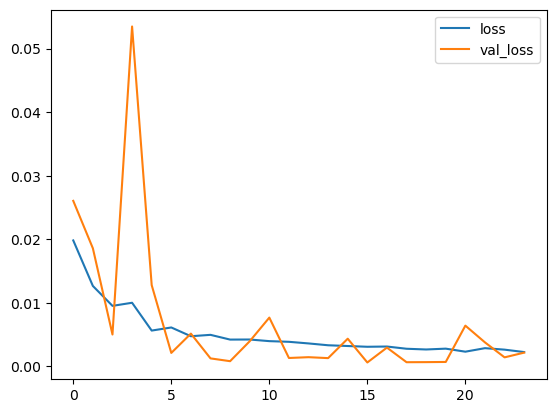

In [33]:
# Plot losses in the dataframe.

losses.plot()
plt.show();

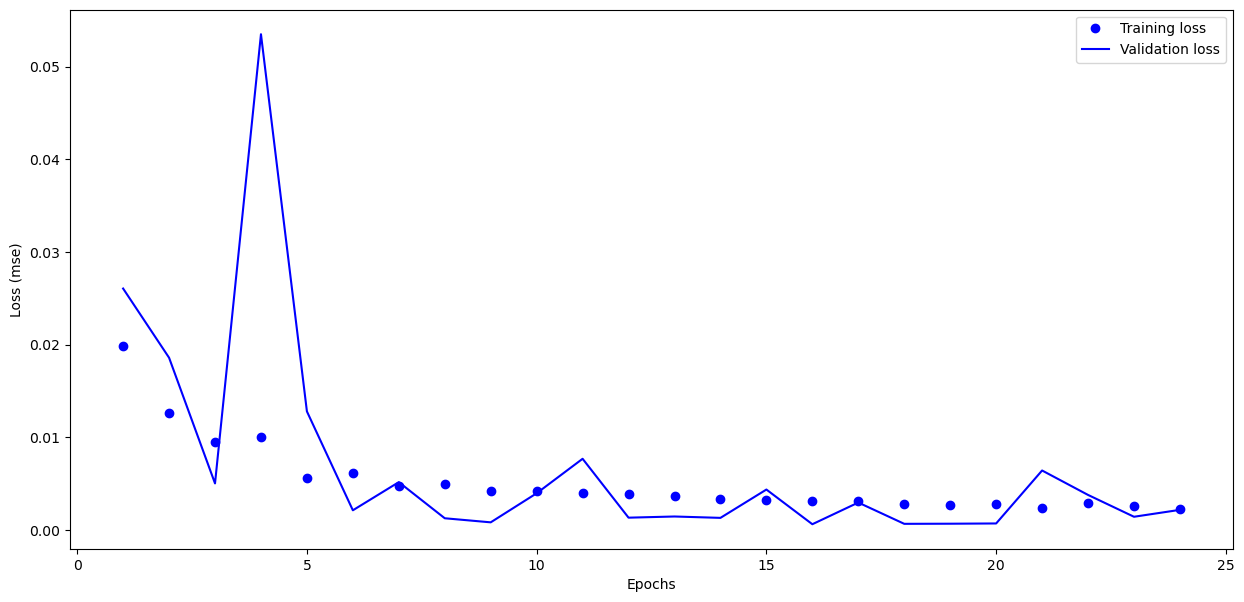

In [34]:
# print Loss for the neural network training process

history_dict = history.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

### Evaluate on Test Data

In [35]:
# Print the last 15 values of the 

print(scaled_train[-15:])

[[0.61523282]
 [0.64077617]
 [0.5909502 ]
 [0.59621235]
 [0.62693562]
 [0.55844547]
 [0.58834653]
 [0.69254803]
 [1.        ]
 [0.44788555]
 [0.49031162]
 [0.59566421]
 [0.58804506]
 [0.63913175]
 [0.59166278]]


In [36]:
first_eval_batch = scaled_train[-length:]
first_eval_batch

array([[0.59621235],
       [0.62693562],
       [0.55844547],
       [0.58834653],
       [0.69254803],
       [1.        ],
       [0.44788555],
       [0.49031162],
       [0.59566421],
       [0.58804506],
       [0.63913175],
       [0.59166278]])

In [37]:
n_input = 12
first_eval_batch = first_eval_batch.reshape((1, n_input, n_features))
first_eval_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

In [38]:
first_eval_batch.size

12

In [96]:
#model.predict?

In [39]:
model.predict(first_eval_batch)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


array([[0.63436]], dtype=float32)

In [40]:
# compare with the true result

scaled_test[0]

array([0.60665442])

## Try predicting the series!

In [41]:
test_predictions = []

first_eval_batch = scaled_train[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

current_batch

array([[[0.59621235],
        [0.62693562],
        [0.55844547],
        [0.58834653],
        [0.69254803],
        [1.        ],
        [0.44788555],
        [0.49031162],
        [0.59566421],
        [0.58804506],
        [0.63913175],
        [0.59166278]]])

In [42]:
for i in range(len(test)):
    
    #print(i)
    
    # get prediction 1 time stamp ahead ([0] is for 
    # grabbing just the number instead of [array])
    
    current_pred = model.predict(current_batch)[0]
    
    # store prediction
    test_predictions.append(current_pred) 
    
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

    

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 267ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step


In [43]:
test_predictions

[array([0.63436], dtype=float32),
 array([0.6713495], dtype=float32),
 array([0.6390938], dtype=float32),
 array([0.6503751], dtype=float32),
 array([0.7657088], dtype=float32),
 array([1.0866517], dtype=float32),
 array([0.54293394], dtype=float32),
 array([0.5842121], dtype=float32),
 array([0.6440825], dtype=float32),
 array([0.6605531], dtype=float32),
 array([0.6942508], dtype=float32),
 array([0.67512286], dtype=float32),
 array([0.6911862], dtype=float32),
 array([0.7216138], dtype=float32),
 array([0.7100329], dtype=float32),
 array([0.7191646], dtype=float32),
 array([0.8462815], dtype=float32),
 array([1.1822486], dtype=float32)]

### Inverse Transformations and Compare



In [ ]:
#scaler.inverse_transform?

In [44]:
# Undo the scaling of X according to feature_range

true_predictions = scaler.inverse_transform(test_predictions)
true_predictions

array([[25921.89388162],
       [27271.53013515],
       [26094.61607462],
       [26506.23728776],
       [30714.41713631],
       [42424.65995228],
       [22586.03070116],
       [24092.14778107],
       [26276.63768965],
       [26877.60087669],
       [28107.12974477],
       [27409.20768678],
       [27995.31050181],
       [29105.5236097 ],
       [28682.96970373],
       [29016.15912175],
       [33654.27412939],
       [45912.70439005]])

In [45]:
# IGNORE WARNINGS

test['Predictions'] = true_predictions

C:\Users\vital\AppData\Local\Temp\ipykernel_54156\3095654106.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['Predictions'] = true_predictions


## Check and plot predictions

In [46]:
# Print the test variable.

test

,Sales,Predictions
observation_date,,
2023-07-01,24911,25921.893882
2023-08-01,26657,27271.530135
2023-09-01,23332,26094.616075
2023-10-01,23933,26506.237288
2023-11-01,28580,30714.417136
2023-12-01,40684,42424.659952
2024-01-01,19188,22586.030701
2024-02-01,22005,24092.147781
2024-03-01,24986,26276.637690


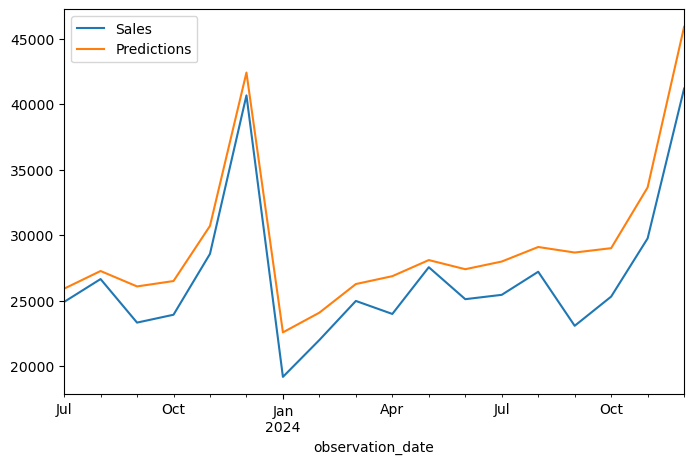

In [47]:
# Plot actual sales and predictions

test.plot(figsize=(8,5))
plt.show()

### Retrain and Forecasting



In [48]:
full_scaler = MinMaxScaler()
scaled_full_data = full_scaler.fit_transform(df)

In [49]:
#full_scaler.fit_transform?

In [50]:
print(scaled_full_data.max())
print(scaled_full_data.min())

1.0
0.0


In [51]:
length = 12 # Length of the output sequences (in number of timesteps)

generator = TimeseriesGenerator(scaled_full_data, 
                                scaled_full_data, length=length, batch_size=1)

In [57]:
# Use any neural network model based on RNN
# You can also use the model created above

model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(length, n_features)))
model.add(Dense(1))

C:\Users\vital\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [58]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 100)            │        40,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,901 (159.77 KB)

 Trainable params: 40,901 (159.77 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
# your code to compile the model

model.compile(optimizer='adam', loss='mse')

In [60]:
# Your code to create an object early-stop

# Use the patience parameter equal to the last digit in your SID.
# However,
# If the last digit of your SID = 0, then assign patience=10
# If the last digit of your SID = 1, then assign patience=11
# If the last digit of your SID = 2, then assign patience=12
# If the last digit of your SID = 3, then assign patience=13

# For example, your SID = 22984879, then patience=9
# One more example: your SID = 22984883, then patience=13

LAST_DIGIT_IN_YOUR_SID = 9

early_stop = EarlyStopping(monitor='val_loss',patience=LAST_DIGIT_IN_YOUR_SID)



In [61]:
# fit model
# IGNORE THE WARNING

history_2 =  model.fit(generator,  epochs=30,
                    validation_data=validation_generator,
                    callbacks=[early_stop])

Epoch 1/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 0.0192 - val_loss: 0.0258
Epoch 2/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - loss: 0.0116 - val_loss: 0.0154
Epoch 3/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 11s 30ms/step - loss: 0.0078 - val_loss: 0.0157
Epoch 4/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step - loss: 0.0054 - val_loss: 0.0071
Epoch 5/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step - loss: 0.0050 - val_loss: 0.0029
Epoch 6/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step - loss: 0.0044 - val_loss: 0.0049
Epoch 7/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - loss: 0.0042 - val_loss: 0.0022
Epoch 8/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0035 - val_loss: 0.0012
Epoch 9/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.0035 - val_loss: 0.0058
Epoch 10/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - loss: 0.0041 - val_loss: 3.2929e-04
Epoch 11/30
384/384 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - loss: 0.0035 - val_loss: 0.0019
Epoch 12/30
384/384 ━━━━━━━━━━

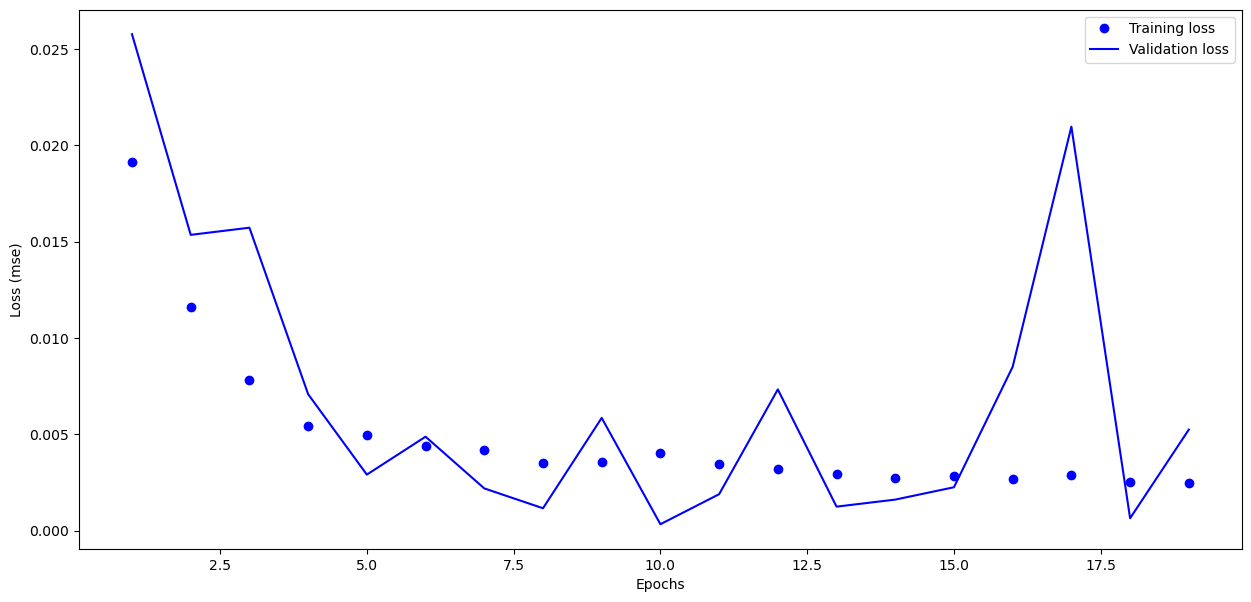

In [62]:
# print Loss for the neural network training process

history_dict = history_2.history

acc_values = history_dict['loss']
val_acc_values = history_dict['val_loss']
epochs = range(1, len(acc_values) + 1)

plt.figure(num=1, figsize=(15,7))
plt.plot(epochs, acc_values, 'bo', label='Training loss')
plt.plot(epochs, val_acc_values, 'b', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (mse)')
plt.legend()

plt.show()

In [63]:
forecast = []
# Replace periods with whatever forecast length you want
periods = 12

first_eval_batch = scaled_full_data[-length:]
current_batch = first_eval_batch.reshape((1, length, n_features))

for i in range(periods):
    
    # get prediction 1 time stamp ahead ([0] is for 
    # grabbing just the number instead of [array])
    current_pred = model.predict(current_batch)[0]
    
    # store prediction forecast.append(current_pred)
    forecast.append(current_pred) 
    
    # update batch to now include prediction and drop first value
    current_batch = np.append(current_batch[:,1:,:],[[current_pred]],axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step


In [64]:
forecast = scaler.inverse_transform(forecast)
forecast

array([[17982.46448171],
       [20043.93604216],
       [22111.94938499],
       [21653.10902989],
       [23950.22720504],
       [22215.15644103],
       [22358.09917057],
       [23854.77329201],
       [20856.71009427],
       [22225.95429659],
       [26366.14788884],
       [35111.22780091]])

### Creating new timestamp index with pandas.



In [65]:
df

,Sales
observation_date,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558
...,...
2024-08-01,27215
2024-09-01,23088
2024-10-01,25318


##### Forecast for next 12 months

In [66]:
forecast_index = pd.date_range(start='2025-01-01',periods=periods,freq='MS')
forecast_index

DatetimeIndex(['2025-01-01', '2025-02-01', '2025-03-01', '2025-04-01',
               '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
               '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [89]:
#pd.date_range?

In [67]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index,
                           columns=['Forecast'])

In [68]:
forecast_df

,Forecast
2025-01-01,17982.464482
2025-02-01,20043.936042
2025-03-01,22111.949385
2025-04-01,21653.109030
2025-05-01,23950.227205
2025-06-01,22215.156441
2025-07-01,22358.099171
2025-08-01,23854.773292
2025-09-01,20856.710094
2025-10-01,22225.954297


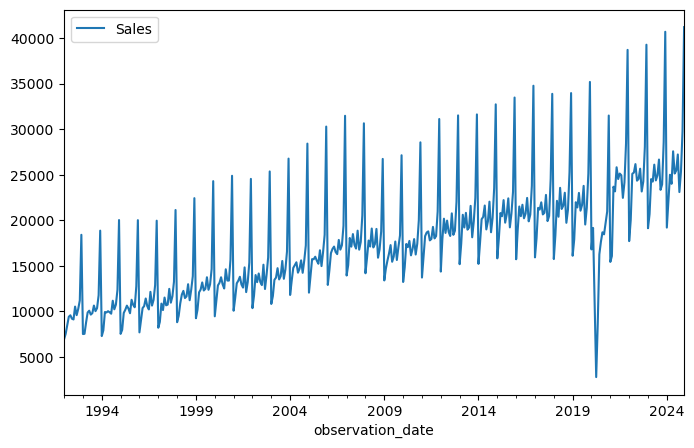

In [69]:
# Plot sales - Values in dataframe

df.plot(figsize=(8,5))
plt.show();

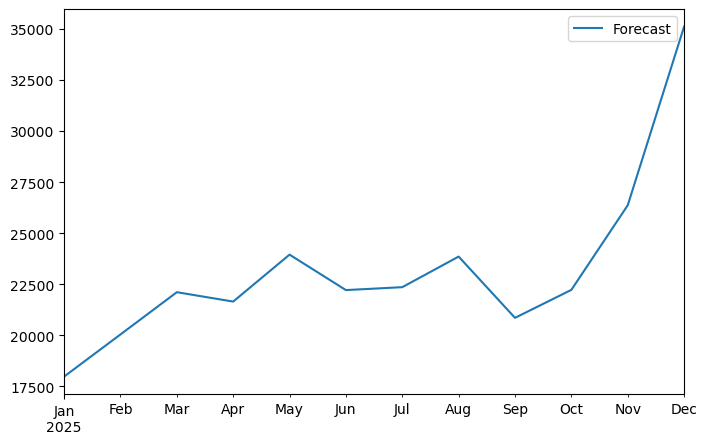

In [70]:
# Plot forecast - Values in forecast_df

forecast_df.plot(figsize=(8,5))
plt.show();

### Joining pandas plots

https://stackoverflow.com/questions/13872533/plot-different-dataframes-in-the-same-figure

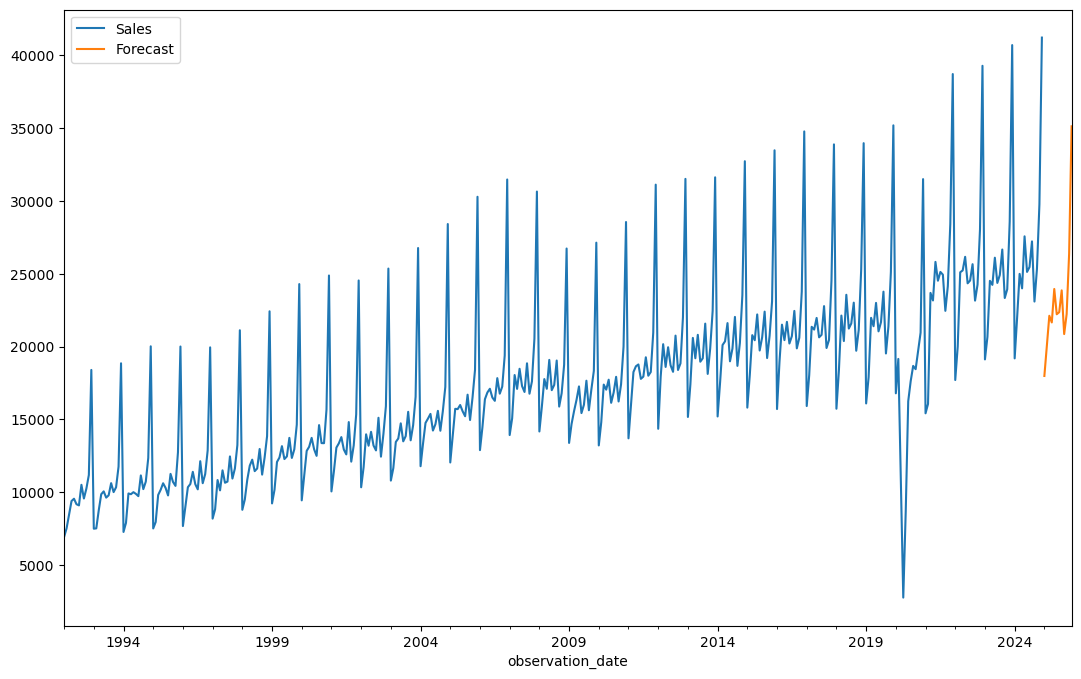

In [71]:
ax = df.plot(figsize=(13,8))
forecast_df.plot(ax=ax)
plt.show();

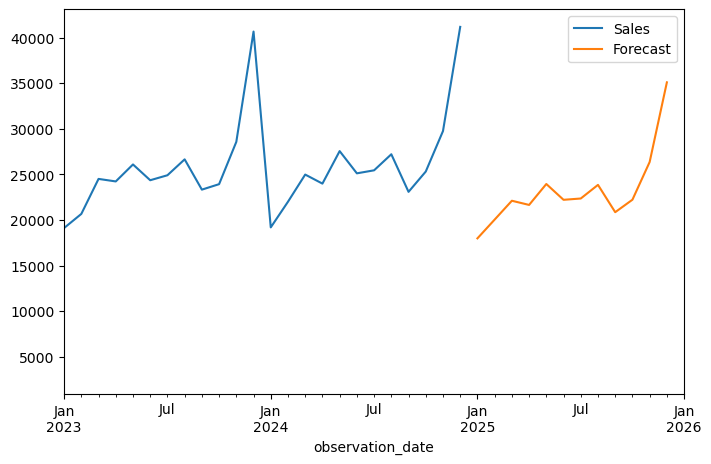

In [72]:
ax = df.plot(figsize=(8,5))
forecast_df.plot(ax=ax)
plt.xlim('2023-01-01','2026-01-01')
plt.show();

### Checking Forecast for last 12 months

In [73]:
forecast_index = pd.date_range(start='2024-01-01', periods=periods, freq='MS')
forecast_index

DatetimeIndex(['2024-01-01', '2024-02-01', '2024-03-01', '2024-04-01',
               '2024-05-01', '2024-06-01', '2024-07-01', '2024-08-01',
               '2024-09-01', '2024-10-01', '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [74]:
forecast_df = pd.DataFrame(data=forecast, index=forecast_index,
                           columns=['Forecast'])

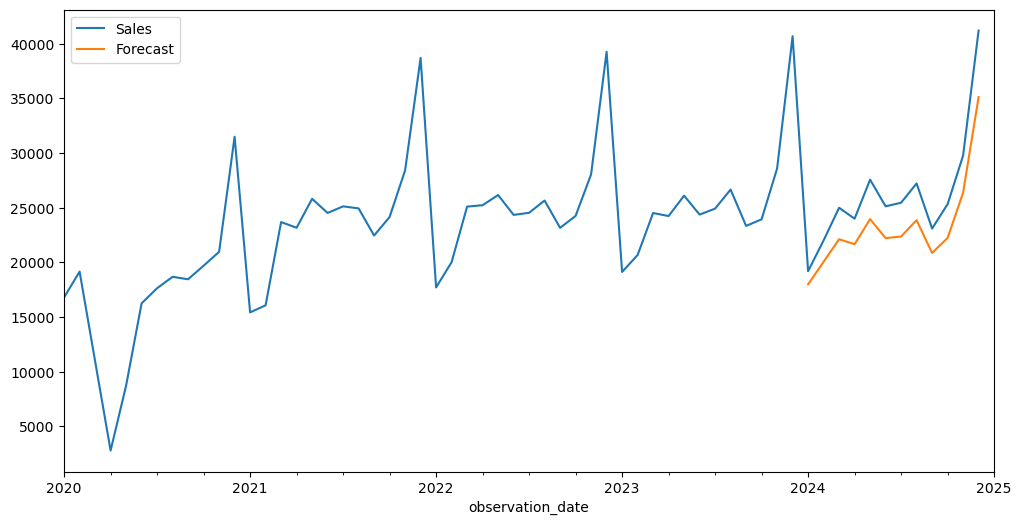

In [75]:
ax = df.plot(figsize=(12,6))
forecast_df.plot(ax=ax)
plt.xlim('2020-01-01','2025-01-01')
plt.show();

<html> <h2 style="font-style:bold; color:red;"> Lab Logbook requirements </h2> </html>

### 1. Record the 2nd model's code & plot the summary()

### 2. Copy your early-stop code and history_2 fit-training-process

### 3. Record the plot of validation and test loss of history_2.

### 4. Based on this analysis, determine the optimal number of epochs for training your model. 

### 5. Record the plot of the Checking Forecast for the last 12 months (last graph).

# Try the same example with a LSTM and/or GRU! (Optional)
